# ANALISIS DE CASAS

## OBJETIVO
1. Encontrar las casas con mejor Beneficio-Precio segun las caracteristicas de la vivienda
- Para este punto debemos identificar por grupos de variables categoricas cuales son los mejores precios
2. Encontrar Outliers de las casas, puede que algunas casas cuesten mas de lo que realmente deben valer segun sus caracteristicas
3. Construir un modelo de regresion para predecir precios de las casas


## lIBRERÍAS

In [103]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Advertencias
import warnings
warnings.filterwarnings('ignore')

#Graficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [104]:
url = "https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/master/data/SaratogaHouses.csv"
df= pd.read_csv(url)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            1728 non-null   int64  
 1   lotSize          1728 non-null   float64
 2   age              1728 non-null   int64  
 3   landValue        1728 non-null   int64  
 4   livingArea       1728 non-null   int64  
 5   pctCollege       1728 non-null   int64  
 6   bedrooms         1728 non-null   int64  
 7   fireplaces       1728 non-null   int64  
 8   bathrooms        1728 non-null   float64
 9   rooms            1728 non-null   int64  
 10  heating          1728 non-null   object 
 11  fuel             1728 non-null   object 
 12  sewer            1728 non-null   object 
 13  waterfront       1728 non-null   object 
 14  newConstruction  1728 non-null   object 
 15  centralAir       1728 non-null   object 
dtypes: float64(2), int64(8), object(6)
memory usage: 216.1+ KB


In [106]:
# cambiar las columans de ingles a español
df = df.rename(columns={'price': 'precio', 'lotSize': 'tamañoLote', 'age':'edad', 'landValue': 'valorTerreno',
                       'livingArea':'SuperficieHabitable', 'pctCollege':'pctUniversidad', 'bedrooms':'dormitorios', 'fireplaces':'chimeneas', 'rooms':'habitaciones',
                        'heating':'calefaccion', 'sewer':'alcantarillado', 'waterfront':'muelle', 'newConstruction':'NuevaConstruccion', 'centralAir':'aireCentral', 'bathrooms':'baños'})

## EDA ANALISIS DE DATOS EXPLORATORIOS

### Variables datos_numericos

In [109]:
# Descripción de los datos
df.describe()

,precio,tamañoLote,edad,valorTerreno,SuperficieHabitable,pctUniversidad,dormitorios,chimeneas,baños,habitaciones
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,211966.705440,0.500214,27.916088,34557.187500,1754.975694,55.567708,3.154514,0.601852,1.900174,7.041667
std,98441.391015,0.698680,29.209988,35021.168056,619.935553,10.333581,0.817351,0.556102,0.658352,2.316453
min,5000.000000,0.000000,0.000000,200.000000,616.000000,20.000000,1.000000,0.000000,0.000000,2.000000
25%,145000.000000,0.170000,13.000000,15100.000000,1300.000000,52.000000,3.000000,0.000000,1.500000,5.000000
50%,189900.000000,0.370000,19.000000,25000.000000,1634.500000,57.000000,3.000000,1.000000,2.000000,7.000000
75%,259000.000000,0.540000,34.000000,40200.000000,2137.750000,64.000000,4.000000,1.000000,2.500000,8.250000
max,775000.000000,12.200000,225.000000,412600.000000,5228.000000,82.000000,7.000000,4.000000,4.500000,12.000000


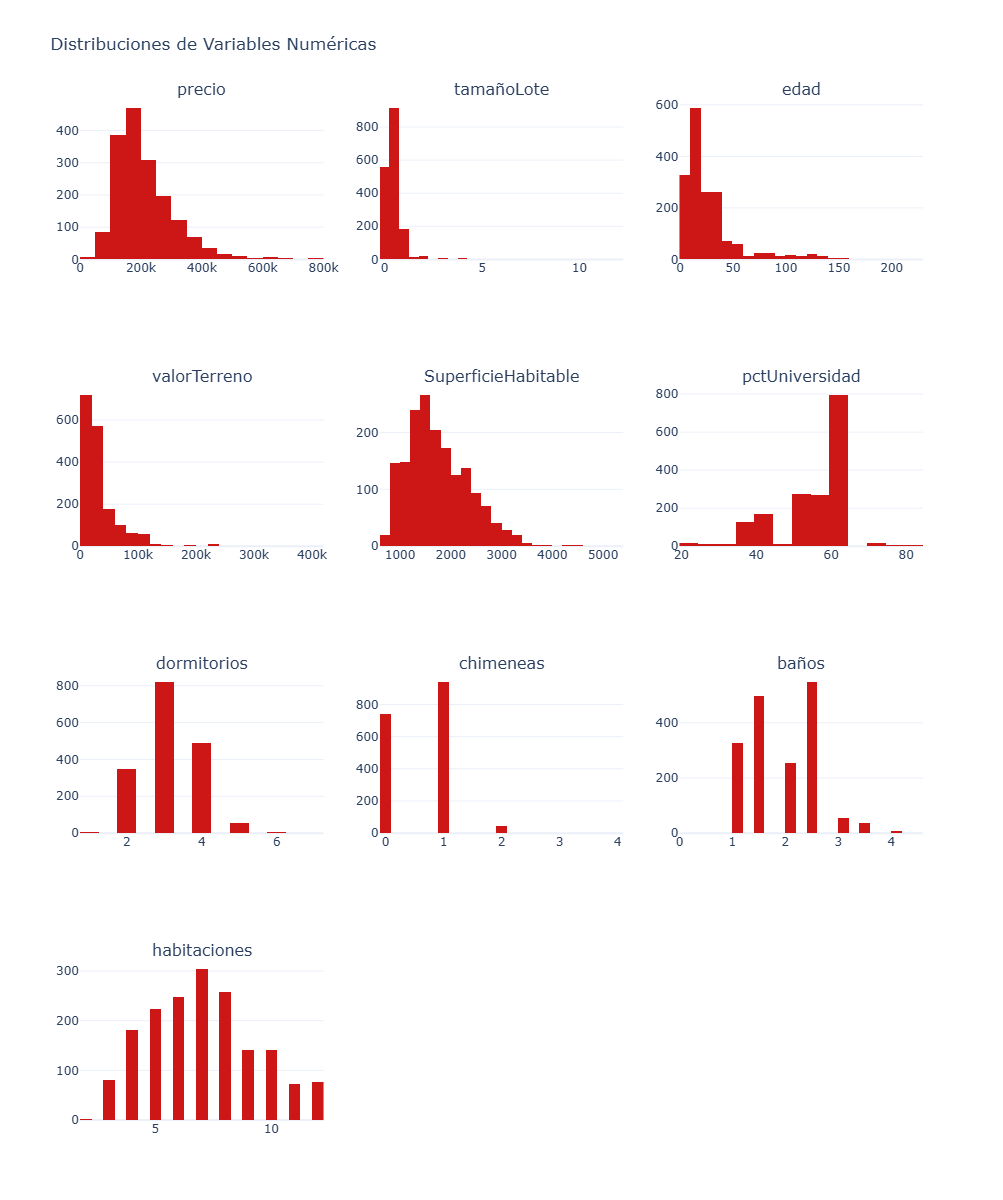

In [110]:
# Datos Numericos
datos_numericos = df.select_dtypes(include=['int', 'float']).columns.tolist()

cols = 3
rows = (len(datos_numericos)+ cols - 1) // cols

#crear subgraficos
fig = make_subplots(rows=rows, cols=cols, subplot_titles=datos_numericos)

#Agregar histogramas por variable
for i, var in enumerate(datos_numericos):
    row = i // cols + 1
    col = i % cols + 1
    fig.add_trace(
        go.Histogram(x=df[var], name=var, marker_color="#cd1616", nbinsx=30),
        row=row, col=col
    )
    
# Ajustes de presentación
fig.update_layout(
    height=300 * rows,
    width=1400,
    title_text='Distribuciones de Variables Numéricas',
    template='plotly_white',
    showlegend=False
)

fig.show()

## BOXPLOT VARIABLES datos_numericos

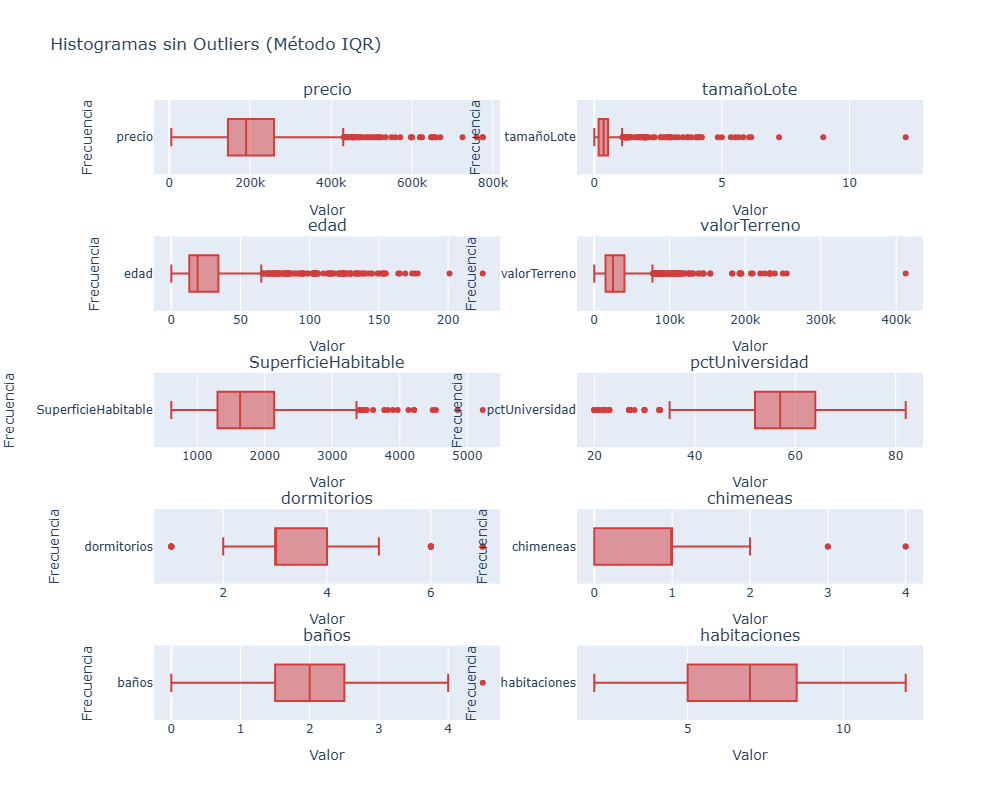

In [112]:
# Número de columnas por fila (ajústalo según cuántas variables tengas)
cols = 2
rows = (len(datos_numericos) + cols - 1) // cols  # redondeo hacia arriba

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=datos_numericos)

# Agregar un histograma por variable
for i, var in enumerate(datos_numericos):
    row = i // cols + 1
    col = i % cols + 1
    fig.add_trace(
        go.Box(x=df[var], name=var, marker_color="#d13e3e"),
        row=row, col=col
    )
    
# Actualizar diseño
fig.update_layout(height=800, width=1300, title_text="Histogramas sin Outliers (Método IQR)",
                  showlegend=False)
fig.update_xaxes(title_text="Valor")
fig.update_yaxes(title_text="Frecuencia")

fig.show()

## EDA VARIABLES CATEGORICAS

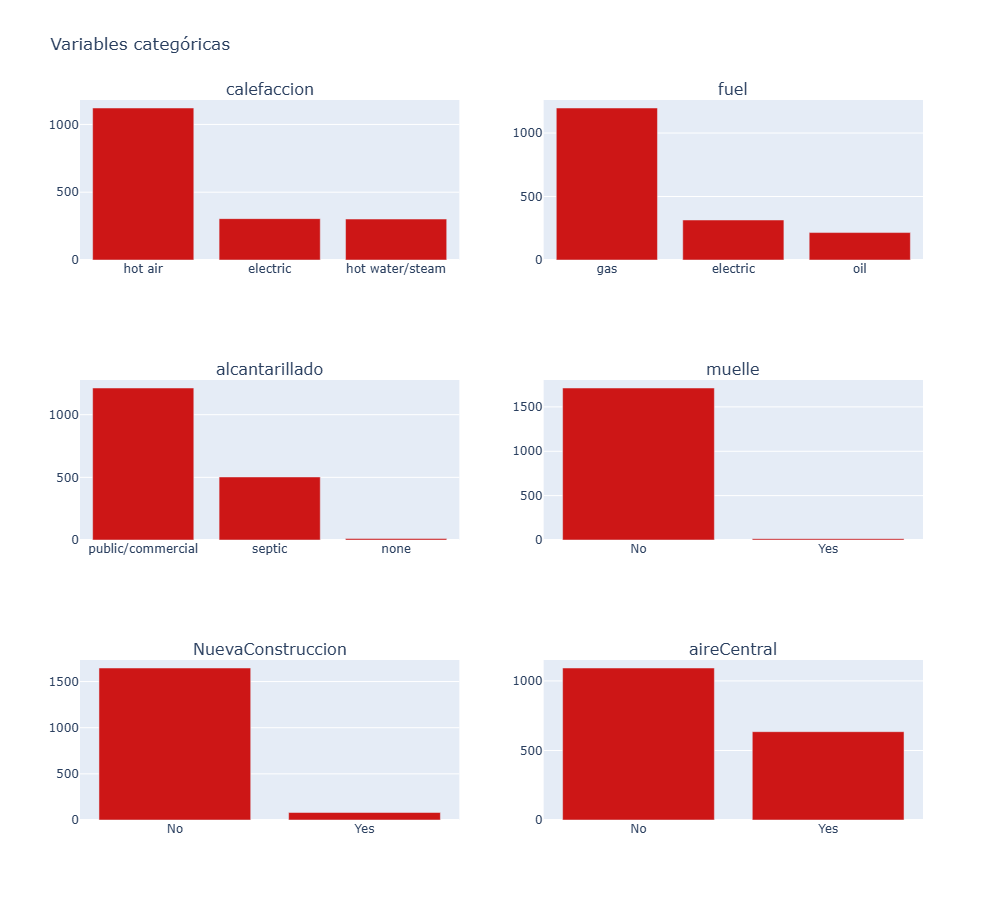

In [114]:
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

cols = 2
rows = (len(categoricas) + cols - 1) // cols

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=categoricas)

# Agregar un gráfico de barras por cada variable categórica
for i, var in enumerate(categoricas):
    row = i // cols + 1
    col = i % cols + 1
    
    # Contar frecuencias de cada categoría y ordenar de forma descendente
    value_counts = df[var].value_counts().sort_values(ascending=False)
    
    fig.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values, name=var, marker_color="#cd1616"),
        row=row, col=col
    )
        
# Ajustes de presentación
fig.update_layout(
    height=300 * rows,
    width=1400,
    title_text='Variables categóricas',
    template='plotly',
    showlegend=False
)

fig.show()

### VARIABLES CATEGORICAS POR PRECIO

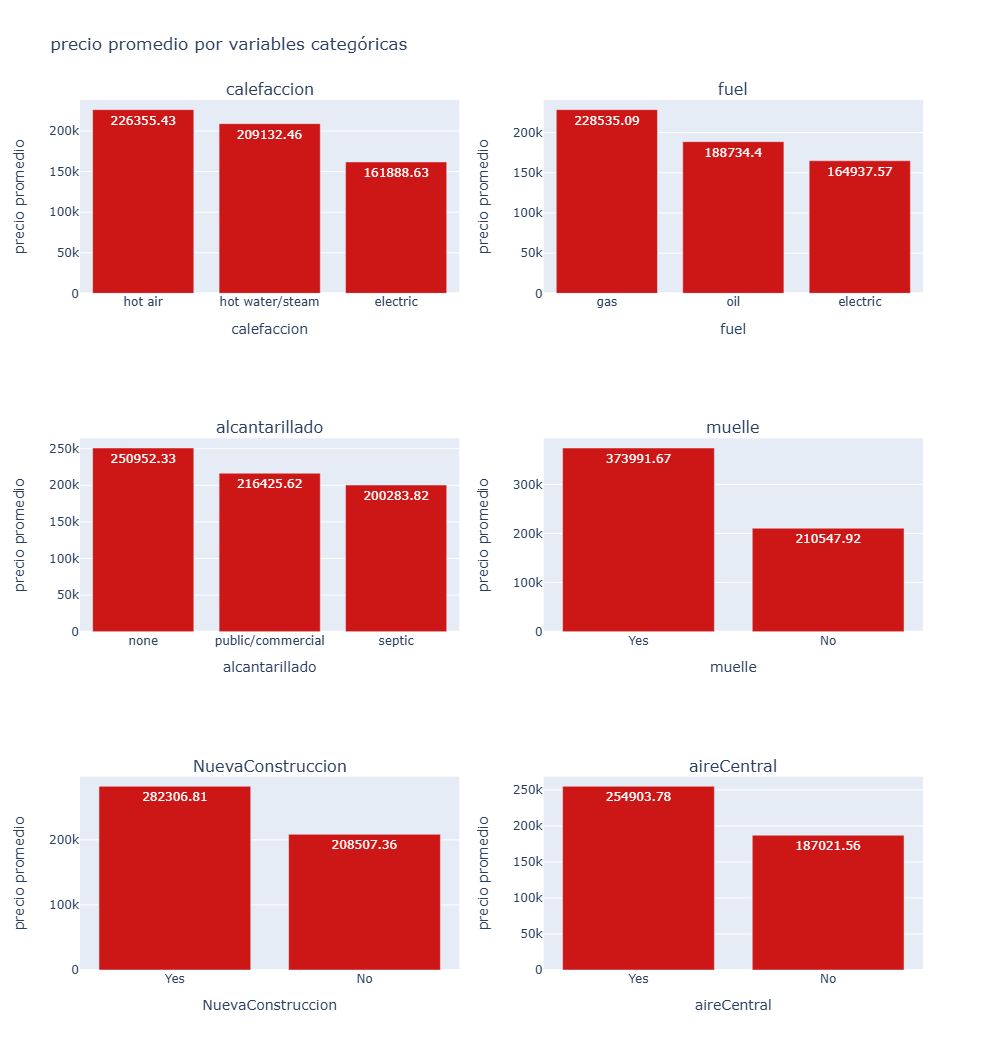

In [116]:
### Variables categoricas por precio

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Asumiendo que ya tienes un DataFrame llamado df con una columna 'precio'
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

cols = 2
rows = (len(categoricas) + cols - 1) // cols

# Crear subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=categoricas)

# Agregar un gráfico de barras por cada variable categórica relacionado con el precio
for i, var in enumerate(categoricas):
    row = i // cols + 1
    col = i % cols + 1
    
    # Calcular el precio promedio por cada categoría
    precio_por_categoria = df.groupby(var)['precio'].mean().sort_values(ascending=False)
    
    fig.add_trace(
        go.Bar(
            x=precio_por_categoria.index, 
            y=precio_por_categoria.values, 
            name=var, 
            marker_color="#cd1616",
            text=precio_por_categoria.values.round(2),  # Mostrar valores en las barras
            textposition='auto'
        ),
        row=row, col=col
    )
    
    # Actualizar títulos de los ejes para cada subplot
    fig.update_xaxes(title_text=var, row=row, col=col)
    fig.update_yaxes(title_text="precio promedio", row=row, col=col)
        
# Ajustes de presentación
fig.update_layout(
    height=350 * rows,  # Un poco más alto para acomodar las etiquetas
    width=1400,
    title_text='precio promedio por variables categóricas',
    template='plotly',
    showlegend=False
)

fig.show()

### Dividir en grupos las variable precio

In [118]:
df['grupo_precios'] = pd.cut(df['precio'], bins=4, labels=['bajo', 'medio_bajo', 'medio', 'alto'])
df[['precio', 'grupo_precios']].head()

,precio,grupo_precios
0,132500,bajo
1,181115,bajo
2,109000,bajo
3,155000,bajo
4,86060,bajo


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   precio               1728 non-null   int64   
 1   tamañoLote           1728 non-null   float64 
 2   edad                 1728 non-null   int64   
 3   valorTerreno         1728 non-null   int64   
 4   SuperficieHabitable  1728 non-null   int64   
 5   pctUniversidad       1728 non-null   int64   
 6   dormitorios          1728 non-null   int64   
 7   chimeneas            1728 non-null   int64   
 8   baños                1728 non-null   float64 
 9   habitaciones         1728 non-null   int64   
 10  calefaccion          1728 non-null   object  
 11  fuel                 1728 non-null   object  
 12  alcantarillado       1728 non-null   object  
 13  muelle               1728 non-null   object  
 14  NuevaConstruccion    1728 non-null   object  
 15  aireCentral          

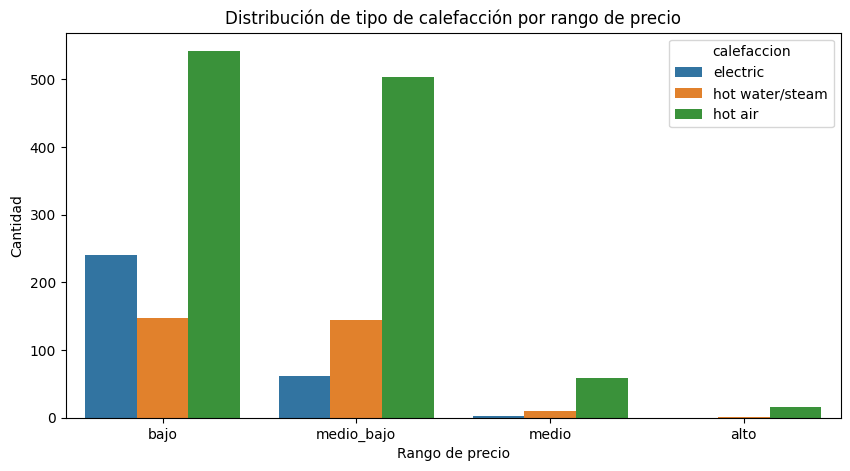

In [177]:
# Conteo de heating por rango de precio
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='grupo_precios', hue='calefaccion')
plt.title('Distribución de tipo de calefacción por rango de precio')
plt.xlabel('Rango de precio')
plt.ylabel('Cantidad')
plt.show()

#### seaborn graficos por grupo precios

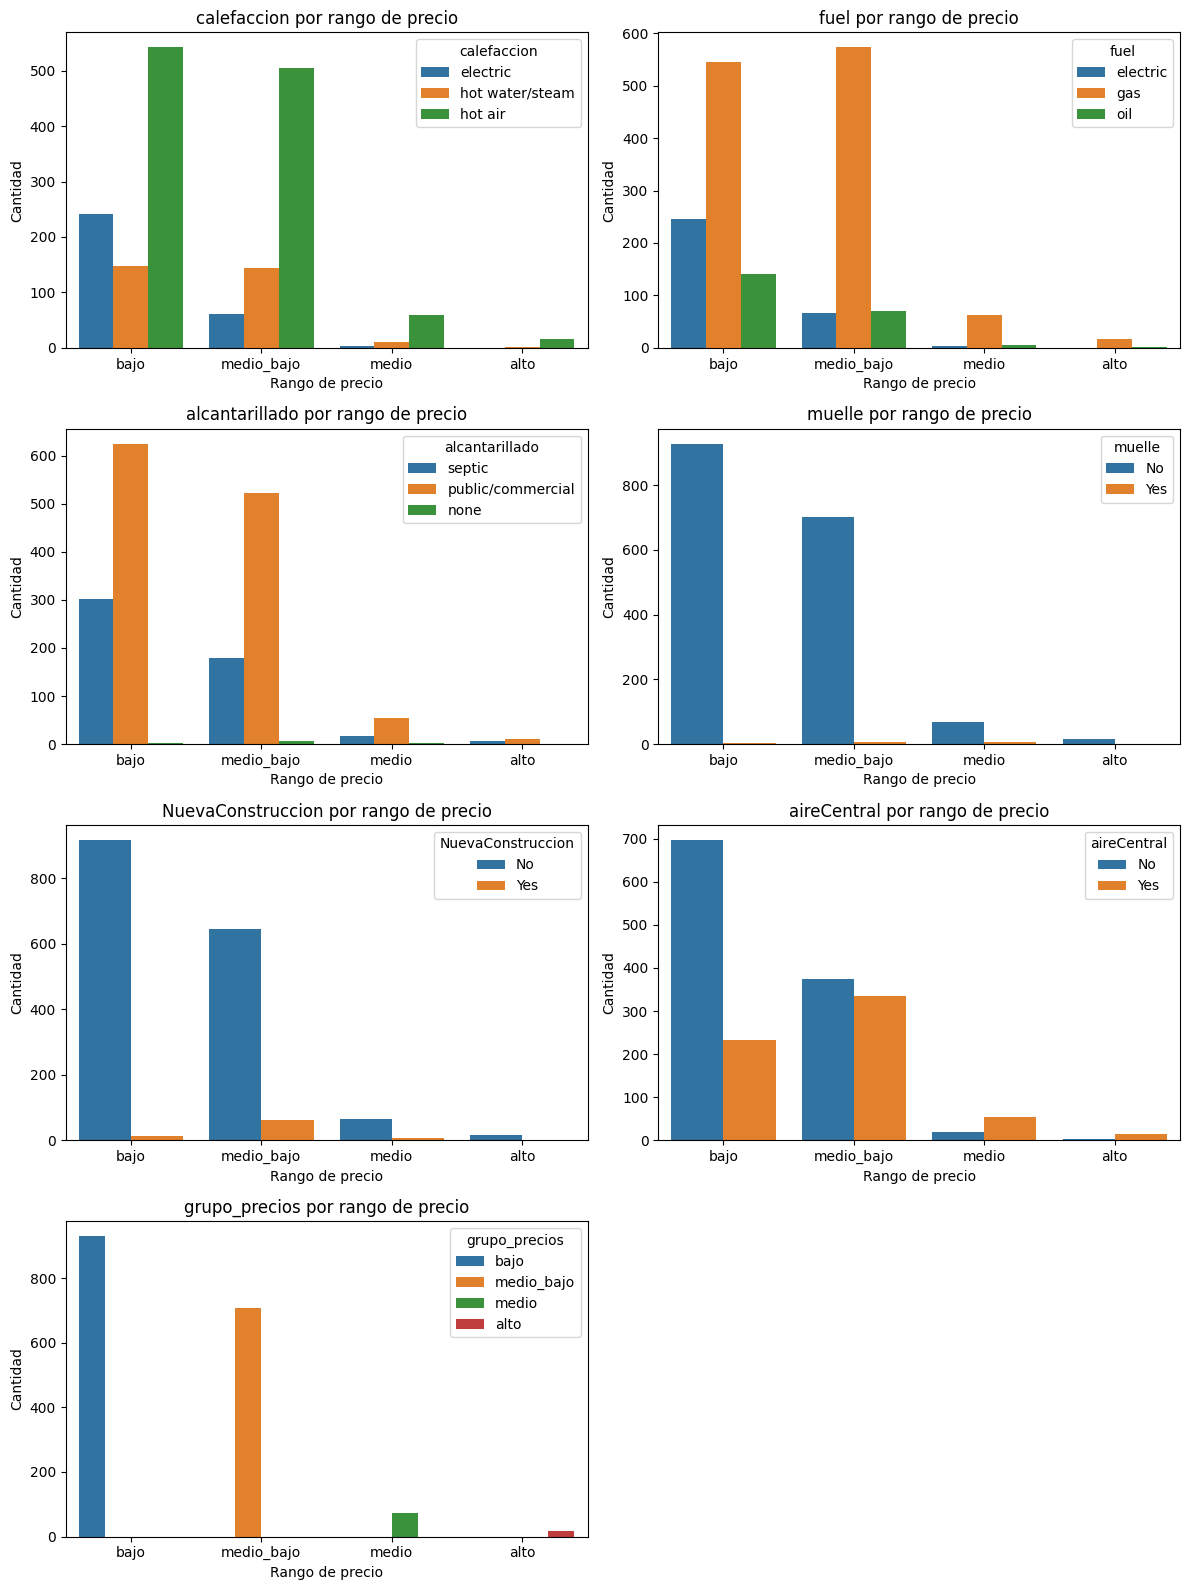

In [186]:
# 2. Detectar variables categóricas (tipo object o category)
categoricas = df.select_dtypes(include=['object', 'category']).columns

# 3. Configurar subplots
n = len(categoricas)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

# 4. Graficar cada variable
for i, var in enumerate(categoricas):
    sns.countplot(data=df, x='grupo_precios', hue=var, ax=axes[i])
    axes[i].set_title(f'{var} por rango de precio')
    axes[i].set_xlabel('Rango de precio')
    axes[i].set_ylabel('Cantidad')
    axes[i].legend(title=var, loc='best')

# 5. Ocultar ejes vacíos si hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [221]:
from sklearn.preprocessing import MinMaxScaler

# hacemos una copia para no afectar el df original
df_score = df.copy()

# Convertimos las variables categoricas que consideramos importantes en numeros de importancia
df_score['alcantarillado'] = df_score['alcantarillado'].map({'none':0,'septic':1, 'public/commercial':2})
df_score['aireCentral'] = df_score['aireCentral'].map({'Yes':1, 'No':0})

# Seleccionamos las variables que consideramos mas importantes
beneficio_vars = ['habitaciones', 'baños', 'SuperficieHabitable', 'alcantarillado', 'tamañoLote', 'edad', 'aireCentral']

# Normalizar entre 0 y 1
scaler = MinMaxScaler()
df_score[beneficio_vars] = scaler.fit_transform(df_score[beneficio_vars])

# Pesos
pesos = {
    'habitaciones':0.3 , 
    'baños':0.2, 
    'SuperficieHabitable':0.2, 
    'alcantarillado':0.15, 
    'tamañoLote':0.1, 
    'edad':0.05, 
    'aireCentral':0
}
# Calcular índice de beneficio ponderado
df_score['beneficio'] = sum(df_score[var] * peso for var, peso in pesos.items())

# Calcular relación precio-beneficio (beneficio por cada unidad de precio)
df_score['precio_beneficio'] = df_score['beneficio'] / df_score['precio']

# Ordenar de mejor a peor relación
mejores_casas = df_score.sort_values(by='precio_beneficio', ascending=False).head(10)

mejores_casas[['precio', 'beneficio', 'precio_beneficio'] + beneficio_vars]

,precio,beneficio,precio_beneficio,habitaciones,baños,SuperficieHabitable,alcantarillado,tamañoLote,edad,aireCentral
1010,5000,0.431385,0.000086,0.4,0.555556,0.235039,1.0,0.023770,0.017778,1.0
890,10300,0.355259,0.000034,0.4,0.333333,0.064180,1.0,0.013115,0.088889,0.0
850,10300,0.295259,0.000029,0.2,0.333333,0.064180,1.0,0.013115,0.088889,0.0
108,25000,0.271015,0.000011,0.4,0.222222,0.065915,0.5,0.017213,0.333333,0.0
458,20000,0.210695,0.000011,0.2,0.222222,0.069384,0.5,0.042623,0.262222,0.0
1248,62500,0.498253,0.000008,0.9,0.222222,0.475282,0.5,0.081967,0.111111,0.0
132,78500,0.566064,0.000007,1.0,0.222222,0.522116,0.5,0.081967,0.680000,0.0
269,85000,0.582534,0.000007,0.8,0.555556,0.387034,1.0,0.040164,0.000000,1.0
459,60000,0.384555,0.000006,0.5,0.333333,0.074588,1.0,0.000820,0.057778,0.0
738,75500,0.477259,0.000006,0.6,0.444444,0.148742,1.0,0.010656,0.551111,0.0


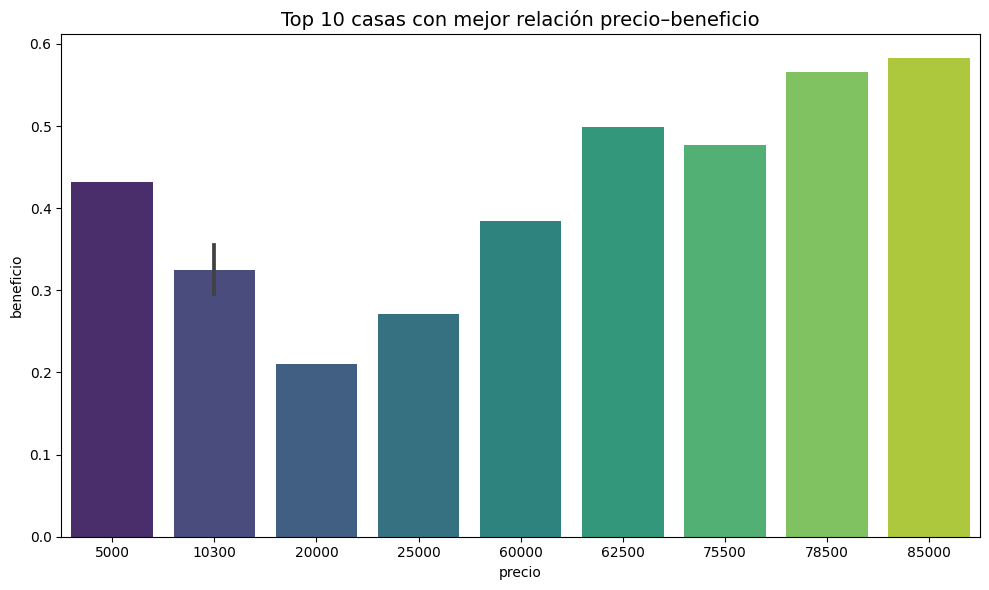

In [253]:
# Ordenar para que la barra más alta aparezca arriba
mejores_casas = mejores_casas.sort_values(by='beneficio', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mejores_casas,
    x='precio',
    y='beneficio',
    palette='viridis'
)

plt.title('Top 10 casas con mejor relación precio–beneficio', fontsize=14)
plt.xlabel('precio')
plt.ylabel('beneficio')
plt.tight_layout()
plt.show()

## HAYAZGOS
1. Casa con los precios mas altos caracteristicas
- calefaccion: hot_air
- fuel: gas
- alcantarillado: publico/comercial
- muelle: no
- nuevas construccione: no
- airecentral: yes

conclusion: las casa mas caras son:
aire caliente, gas, alcantarillado publico, sin muelle, no son nuevas, tienen airecentral

2. Para obtener las casas con mejor precio beneficio; tenemos que definir cuales son las mejores casas y agregarle pesos
- **MEJOR CASA =**
- 5   tamañoLote            
- 6   edad                   
- 3   SuperficieHabitable    
- 2   baños                 
- 1   habitaciones            
- 4   alcantarillado         
- 7   aireCentral            
